# Convoluciones

En esta guía veremos las convoluciones, una operación que hace posible la visión por computador moderna

## Importación de librerías

Primero, importamos PyTorch y las herramientas necesarias para manejar datos y visión por computador.

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# Configuración para mostrar imágenes en gris
plt.rcParams["image.cmap"] = "gray"

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.2.1+cu121


## Cargar y Preprocesar una Imagen
Cargaremos una imagen y la convertiremos a escala de grises porque es más fácil entender las convoluciones en 2D (1 canal) primero.

Imagen redimensionada a: (405, 512)
Dimensiones del tensor: torch.Size([1, 1, 512, 405])


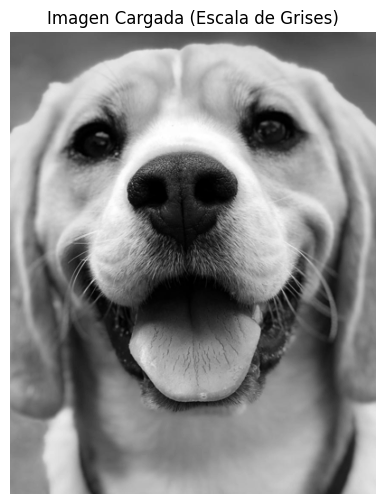

In [4]:
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt
import os


image_path = "perro.jpg"

def load_local_image(path, max_size=512):
    if not os.path.exists(path):
        raise FileNotFoundError(f"No se encontró la imagen en: {path}")
    
    # Cargar y convertir a escala de grises ('L')
    img = Image.open(path).convert('L')
    
    # Redimensionar si es muy grande (para que el notebook no sea lento)
    if max(img.size) > max_size:
        img.thumbnail((max_size, max_size))
        print(f"Imagen redimensionada a: {img.size}")
        
    return img

try:
    img_pil = load_local_image(image_path)
    
    # Convertir a Tensor de PyTorch
    # Las dimensiones deben ser: (Batch_Size, Channels, Height, Width) -> (1, 1, H, W)
    transform = torch.from_numpy(np.array(img_pil)).float()
    input_image = transform.unsqueeze(0).unsqueeze(0)

    print(f"Dimensiones del tensor: {input_image.shape}")

    plt.figure(figsize=(6, 6))
    plt.title("Imagen Cargada (Escala de Grises)")
    plt.imshow(img_pil, cmap='gray')
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Error: {e}")
    print("Por favor verifica que el nombre del archivo y la extensión (jpg, png) sean correctos.")

## Definición de Filtros (Kernels) Manuales
Definiremos los filtros. Esto simula lo que ocurre en las primeras capas de una CNN: extracción de características de bajo nivel.

Vamos a definir:

1. Detector de Bordes Verticales (Sobel X): Resalta cambios de intensidad de izquierda a derecha.

2. Detector de Bordes Horizontales (Sobel Y): Resalta cambios de arriba a abajo.

3. Filtro de Enfoque (Sharpen): Resalta diferencias con el centro.

In [5]:
# 1. Filtro Sobel Vertical (Detecta bordes verticales)
# Observa cómo los números cambian de positivo a negativo horizontalmente
sobel_v = torch.tensor([
    [-1.0, 0.0, 1.0],
    [-2.0, 0.0, 2.0],
    [-1.0, 0.0, 1.0]
])

# 2. Filtro Sobel Horizontal (Detecta bordes horizontales)
# Observa cómo los números cambian de positivo a negativo verticalmente
sobel_h = torch.tensor([
    [-1.0, -2.0, -1.0],
    [ 0.0,  0.0,  0.0],
    [ 1.0,  2.0,  1.0]
])

# 3. Filtro de "Bordes" genérico (Laplaciano aproximado)
# El centro es muy positivo y los vecinos negativos
edge_detect = torch.tensor([
    [-1.0, -1.0, -1.0],
    [-1.0,  8.0, -1.0],
    [-1.0, -1.0, -1.0]
])

# Ajustamos las dimensiones para que PyTorch las entienda
# Dimensiones del Kernel: (Out_Channels, In_Channels, Kernel_Height, Kernel_Width)
kernels = {
    "Bordes Verticales": sobel_v.view(1, 1, 3, 3),
    "Bordes Horizontales": sobel_h.view(1, 1, 3, 3),
    "Detector de Contornos": edge_detect.view(1, 1, 3, 3)
}

## Aplicación de la Convolución
Usamos `F.conv2d` para aplicar los filtros. Esta función desliza (hace el barrido) el kernel sobre la imagen.

In [6]:
def apply_convolution(image, kernel, name):
    # Aplicar convolución
    # padding=1 mantiene el tamaño de la imagen original
    filtered_image = F.conv2d(image, kernel, padding=1)
    return filtered_image

results = {}
for name, kernel in kernels.items():
    results[name] = apply_convolution(input_image, kernel, name)

## Visualización de los Mapas de Características
Aquí veremos qué "ve" la red neuronal después de aplicar cada filtro. Nota cómo el filtro vertical hace que las líneas horizontales desaparezcan y viceversa.

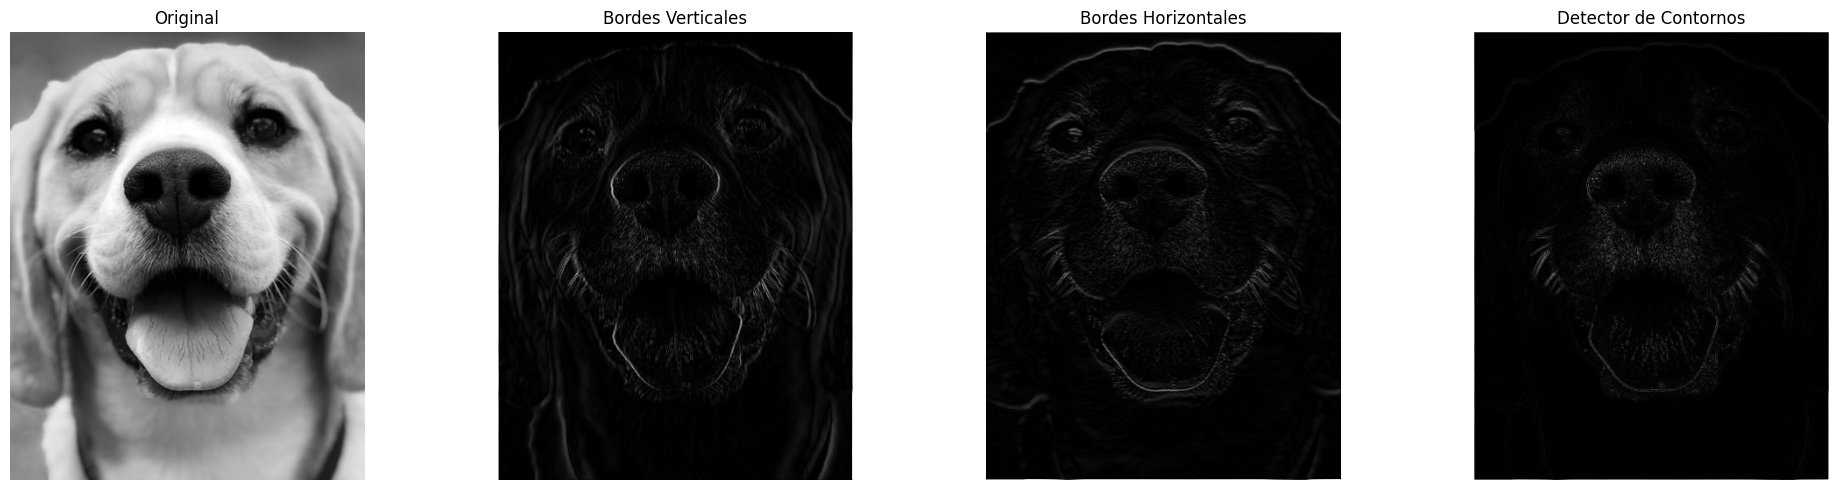

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Original
axes[0].imshow(input_image.squeeze(), cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

# Resultados
for i, (name, res) in enumerate(results.items()):
    # Tomamos valor absoluto porque los bordes pueden ser negativos
    # (cambio de claro a oscuro vs oscuro a claro)
    img_show = torch.abs(res).squeeze().detach().numpy()
    
    axes[i+1].imshow(img_show, cmap='gray')
    axes[i+1].set_title(name)
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

## Experimentación Interactiva (Haz tu propio filtro)
En esta celda puedes cambiar los valores manualmente para ver qué pasa. Por ejemplo, un filtro de promedio (blur) tiene todos los valores positivos iguales.

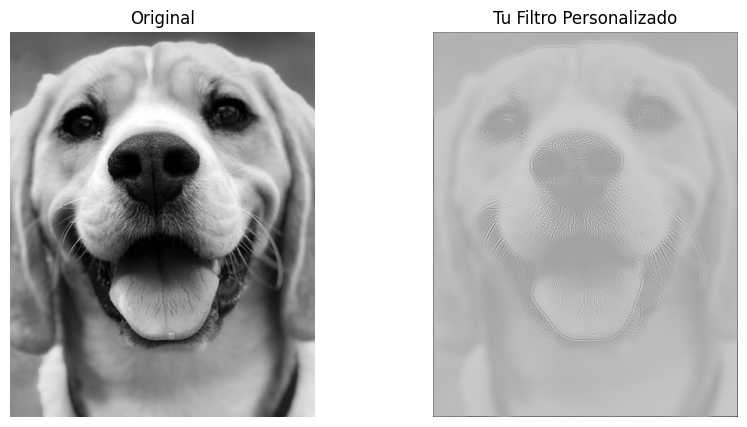

In [8]:
# --- ZONA DE EXPERIMENTACIÓN ---
# Modifica estos 9 valores para crear tu propio efecto
k1, k2, k3 =  1.0,  1.0,  1.0
k4, k5, k6 =  1.0, -7.0,  1.0 # Si la suma es cercana a 0, detecta bordes
k7, k8, k9 =  1.0,  1.0,  1.0
# -------------------------------

custom_kernel = torch.tensor([
    [k1, k2, k3],
    [k4, k5, k6],
    [k7, k8, k9]
]).view(1, 1, 3, 3)

output = F.conv2d(input_image, custom_kernel, padding=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(input_image.squeeze(), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
# Usamos vmin y vmax para mejorar el contraste visual si los valores son muy altos
plt.imshow(output.squeeze().detach(), cmap='gray') 
plt.title("Tu Filtro Personalizado")
plt.axis('off')

plt.show()

## Conclusiones

Este ejercicio es crucial para entender las CNNs (Convolutional Neural Networks).

- En este notebook, tú eres la red neuronal: has decidido manualmente que los valores sean [-1, 0, 1].

- En una CNN real (como las que verás en notebooks futuros), estos 9 números (el kernel) son los parámetros entrenables (pesos).

- A través del descenso de gradiente, la red aprenderá sola que necesita un filtro "tipo Sobel" para detectar bordes y distinguir un zapato de una camisa.